# Module 10: MBS & Prepayment Verification

## PSA Prepayment Models

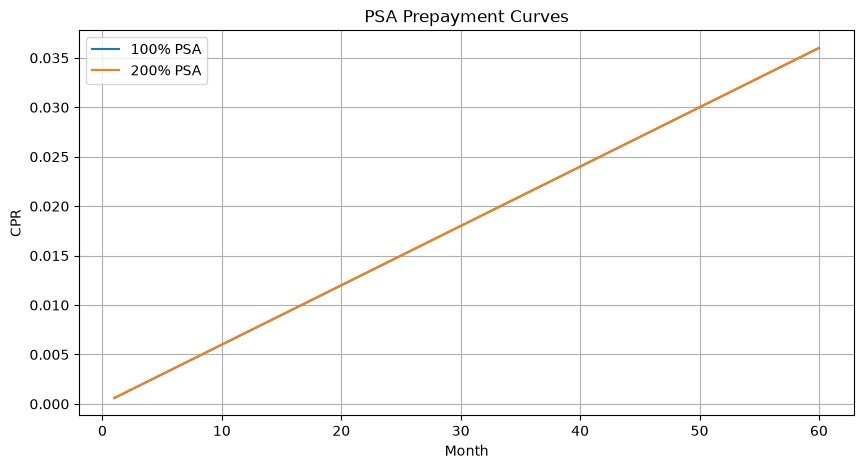

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from src.mbs.prepayment import cpr_to_smm, psa_to_cpr  # noqa: E402
from src.mbs.pass_through import project_cash_flows  # noqa: E402
import matplotlib.pyplot as plt

# PSA Model
months = np.arange(1, 61)
cpr_100 = [psa_to_cpr(m, 100) for m in months]
cpr_200 = [psa_to_cpr(m, 200) for m in months]

plt.figure(figsize=(10, 5))
plt.plot(months, cpr_100, label="100% PSA")
plt.plot(months, cpr_200, label="200% PSA")
plt.title("PSA Prepayment Curves")
plt.xlabel("Month")
plt.ylabel("CPR")
plt.legend()
plt.grid(True)
plt.show()

## Pass-Through Cash Flows

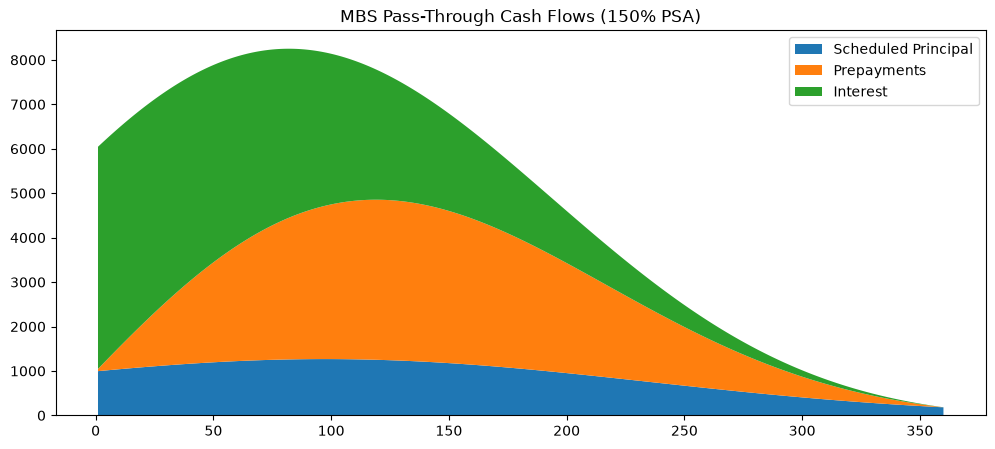

In [2]:
# Pass-Through Cash Flows
balance = 1_000_000
wac = 0.06  # Weighted Average Coupon
term = 360  # 30-year
cpr_curve = [psa_to_cpr(m, 150) for m in range(1, term + 1)]
smm_curve = [cpr_to_smm(cpr) for cpr in cpr_curve]

cashflows = project_cash_flows(balance, wac, term, smm_curve)

# Plot Cashflows
plt.figure(figsize=(12, 5))
plt.stackplot(
    range(1, term + 1),
    cashflows["scheduled_principal"],
    cashflows["prepayment"],
    cashflows["interest"],
    labels=["Scheduled Principal", "Prepayments", "Interest"],
)
plt.legend(loc="upper right")
plt.title("MBS Pass-Through Cash Flows (150% PSA)")
plt.show()

## Richard-Roll Prepayment Model
Demonstrating the new stochastic/behavioral prepayment modeling.

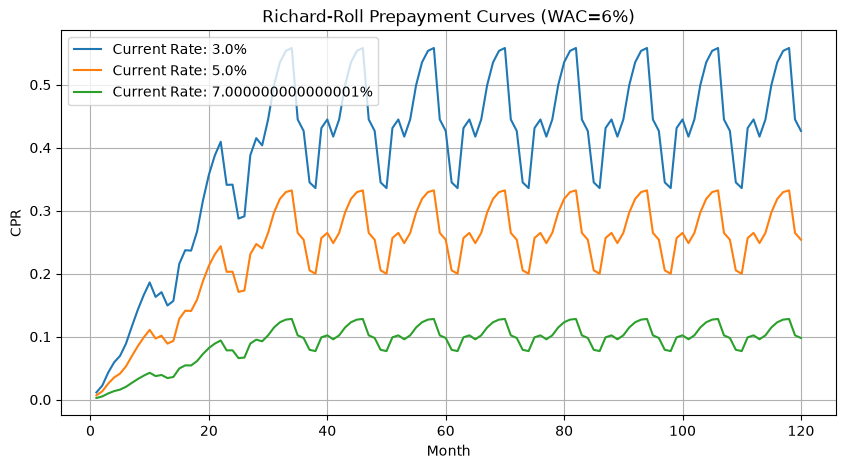

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from src.mbs.prepayment import richard_roll_cpr

months = np.arange(1, 121)
wac = 0.06
rates = [0.03, 0.05, 0.07]  # Different current rates to show refinancing incentive

plt.figure(figsize=(10, 5))
for r in rates:
    cpr_curve = [
        richard_roll_cpr(wac, r, m, m % 12 + 1, pool_factor=1.0) for m in months
    ]
    plt.plot(months, cpr_curve, label=f"Current Rate: {r * 100}%")

plt.title("Richard-Roll Prepayment Curves (WAC=6%)")
plt.xlabel("Month")
plt.ylabel("CPR")
plt.legend()
plt.grid(True)
plt.show()

## Monte Carlo OAS using Hull-White
Pricing the prepayment option using stochastic generated paths.

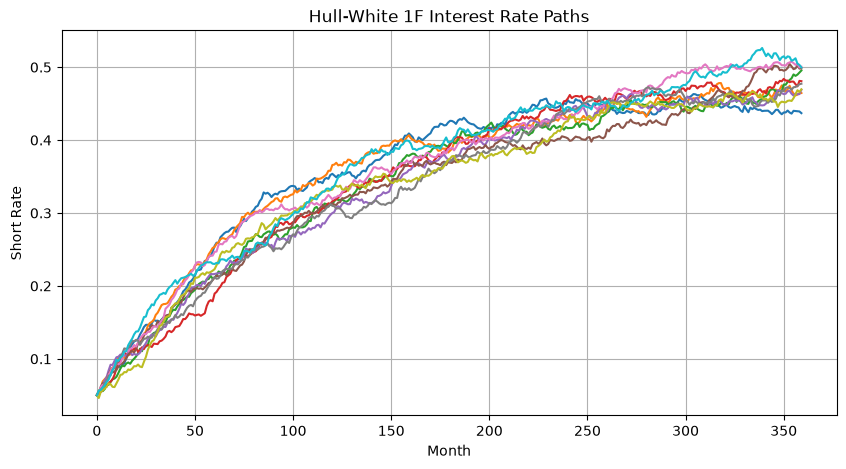

Calculated Monte Carlo OAS: -1437.11 bps


In [4]:
from src.mbs.oas import generate_hw1f_paths, calculate_oas
from src.mbs.pass_through import project_cash_flows

# Generate HW1F paths
n_paths = 100
term = 360
r0 = 0.05
a = 0.1
sigma = 0.01

rate_paths = generate_hw1f_paths(r0, a, sigma, n_paths, term, 1.0 / 12.0, r0)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(rate_paths[i, :])
plt.title("Hull-White 1F Interest Rate Paths")
plt.xlabel("Month")
plt.ylabel("Short Rate")
plt.grid(True)
plt.show()

# Calculate OAS
balance = 100000
wac = 0.06


# We'll use a dynamic prepayment model (richard-roll)
def dynamic_smm_hw(rate_path, wac_val):
    # rate_path is an array of length term
    def smm_func(t, pool_factor):
        # We need the rate at time t
        current_rate = rate_path[t] if t < len(rate_path) else rate_path[-1]
        cpr = richard_roll_cpr(wac_val, current_rate, t + 1, (t % 12) + 1, pool_factor)
        return 1.0 - (1.0 - cpr) ** (1.0 / 12.0)

    return smm_func


# To find OAS, we need a price first. Let's assume price = 101000
price = 101000
oas = calculate_oas(price, balance, wac, term, rate_paths, dynamic_smm_hw)
print(f"Calculated Monte Carlo OAS: {oas * 10000:.2f} bps")